# Обратная задача: восстановление параметров DBM

Цель — восстановить параметры симуляции

$$
\eta,\qquad E_{\mathrm{bd}}^{(0)},\qquad l_c,\qquad k
$$

по морфологическим характеристикам выросшего электрического дерева.

Сначала строится медианный baseline, затем для каждого параметра обучается отдельная модель `RandomForestRegressor`. Качество оценивается по `MAE`, `RMSE` и $R^2$ на validation и test.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline

In [2]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "ml_dataset"
DATA_FILE = DATA_DIR / "dataset_inverse.csv"
RESULTS_DIR = PROJECT_ROOT / "results" / "inverse_ml"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_FILE.is_file(), DATA_FILE

print("Корень проекта:", PROJECT_ROOT)
print("Датасет:", DATA_FILE)
print("Результаты:", RESULTS_DIR)

Корень проекта: /home/artur/PycharmProjects/Mathprac
Датасет: /home/artur/PycharmProjects/Mathprac/data/ml_dataset/dataset_inverse.csv
Результаты: /home/artur/PycharmProjects/Mathprac/results/inverse_ml


In [3]:
from src.morphology_features import MORPHOLOGY_FEATURES

FEATURE_COLUMNS = list(MORPHOLOGY_FEATURES)

TARGET_COLUMNS = [
    "eta",
    "mean_breakdown_field",
    "correlation_length",
    "weibull_shape",
]

TARGET_LABELS = {
    "eta": r"$\eta$",
    "mean_breakdown_field": r"$E_{\mathrm{bd}}^{(0)}$",
    "correlation_length": r"$l_c$",
    "weibull_shape": r"$k$",
}

print("Количество признаков:", len(FEATURE_COLUMNS))
print("Количество целей:", len(TARGET_COLUMNS))

Количество признаков: 27
Количество целей: 4


In [4]:
dataset = pd.read_csv(
    DATA_FILE,
    dtype={
        "disorder_seed": "uint64",
        "random_seed": "uint64",
    },
)

assert dataset["run_id"].notna().all()
assert dataset["run_id"].is_unique
assert set(FEATURE_COLUMNS).issubset(dataset.columns)
assert set(TARGET_COLUMNS).issubset(dataset.columns)

print("Количество деревьев:", len(dataset))
print("Количество столбцов:", dataset.shape[1])

display(dataset.head())

Количество деревьев: 10199
Количество столбцов: 45


,run_id,point_id,phase,split,material_rep,growth_rep,eta,mean_breakdown_field,correlation_length,weibull_shape,...,side_branch_fraction,fractal_dimension,lacunarity_4,lacunarity_8,lacunarity_16,lacunarity_32,radius_25,radius_50,radius_75,radius_90
0,global-000003-m0-g0,global-000003,global,train,0,0,1.188938,2.922237,2,14.289726,...,0.570201,1.104227,18.874065,12.869254,8.149161,3.907883,0.251538,0.413367,0.513323,0.577493
1,global-000007-m0-g0,global-000007,global,train,0,0,0.787852,2.743639,14,2.879581,...,0.753846,1.334038,13.228443,9.041631,5.374523,4.149738,0.262099,0.385465,0.531860,0.579209
2,global-000008-m0-g0,global-000008,global,train,0,0,0.509025,3.220241,4,6.943663,...,0.783430,1.293139,10.306111,6.864251,5.322607,4.029273,0.356272,0.484476,0.551012,0.579618
3,global-000009-m0-g0,global-000009,global,train,0,0,1.839728,2.881764,15,13.146752,...,0.564706,1.235450,19.682768,12.946159,8.039862,3.912803,0.253364,0.401671,0.476231,0.571268
4,global-000010-m0-g0,global-000010,global,train,0,0,2.930976,3.090365,4,2.767735,...,0.409594,1.078427,23.773097,15.340968,8.277883,4.271619,0.266308,0.496383,0.615528,0.667813


In [5]:
display(
    pd.crosstab(
        dataset["split"],
        dataset["status"],
        margins=True,
    )
)

seed_split_count = (
    dataset
    .groupby("disorder_seed")["split"]
    .nunique()
)

leaking_seeds = seed_split_count[seed_split_count > 1]

print(
    "Карт неоднородности в нескольких split:",
    len(leaking_seeds),
)

assert leaking_seeds.empty

status,arrested,breakdown,All
split,,,
test,113,1820,1933
train,875,7391,8266
All,988,9211,10199


Карт неоднородности в нескольких split: 0


In [9]:
train_pool = dataset[
    dataset["split"] == "train"
].copy()

test_data = dataset[
    dataset["split"] == "test"
].copy()

assert train_pool["point_id"].notna().all()

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42,
)

train_indices, validation_indices = next(
    group_split.split(
        train_pool,
        groups=train_pool["point_id"],
    )
)

train_data = train_pool.iloc[train_indices].copy()
validation_data = train_pool.iloc[validation_indices].copy()

X_train = train_data[FEATURE_COLUMNS]
y_train = train_data[TARGET_COLUMNS]

X_validation = validation_data[FEATURE_COLUMNS]
y_validation = validation_data[TARGET_COLUMNS]

X_test = test_data[FEATURE_COLUMNS]
y_test = test_data[TARGET_COLUMNS]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (6560, 27) (6560, 4)
Validation: (1706, 27) (1706, 4)
Test: (1933, 27) (1933, 4)


In [10]:
train_points = set(train_data["point_id"])
validation_points = set(validation_data["point_id"])
test_points = set(test_data["point_id"])

assert train_points.isdisjoint(validation_points)

train_seeds = set(train_data["disorder_seed"])
validation_seeds = set(validation_data["disorder_seed"])
test_seeds = set(test_data["disorder_seed"])

assert train_seeds.isdisjoint(validation_seeds)
assert train_seeds.isdisjoint(test_seeds)
assert validation_seeds.isdisjoint(test_seeds)

print("Общих point_id между train и validation нет")
print("Общих disorder_seed между частями нет")

Общих point_id между train и validation нет
Общих disorder_seed между частями нет


## Медианный baseline

Для каждого параметра строится простая модель, которая всегда предсказывает медиану этого параметра на обучающей выборке.

Random Forest должен давать качество заметно лучше этого baseline.

In [11]:
def calculate_regression_metrics(
    y_true,
    y_pred,
    target,
    model_name,
    split_name,
):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    target_range = (
        y_train[target].max()
        - y_train[target].min()
    )

    normalized_mae = mae / target_range

    return {
        "model": model_name,
        "split": split_name,
        "target": target,
        "mae": mae,
        "normalized_mae": normalized_mae,
        "rmse": rmse,
        "r2": r2,
    }

In [12]:
baseline_models = {}
baseline_predictions = {}
baseline_metrics = []

for target in TARGET_COLUMNS:
    baseline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "model",
                DummyRegressor(strategy="median"),
            ),
        ]
    )

    baseline.fit(
        X_train,
        y_train[target],
    )

    validation_prediction = baseline.predict(
        X_validation
    )

    baseline_models[target] = baseline
    baseline_predictions[target] = validation_prediction

    metrics = calculate_regression_metrics(
        y_true=y_validation[target],
        y_pred=validation_prediction,
        target=target,
        model_name="Median baseline",
        split_name="validation",
    )

    baseline_metrics.append(metrics)

baseline_metrics = pd.DataFrame(baseline_metrics)

display(
    baseline_metrics.round(4)
)

,model,split,target,mae,normalized_mae,rmse,r2
0,Median baseline,validation,eta,0.6644,0.2659,0.7536,-0.0018
1,Median baseline,validation,mean_breakdown_field,0.1433,0.2390,0.1700,-0.0211
2,Median baseline,validation,correlation_length,3.7409,0.2672,4.5937,-0.0716
3,Median baseline,validation,weibull_shape,3.3022,0.2542,3.8738,-0.0054


## Random Forest

Для каждого параметра обучается отдельный `RandomForestRegressor`.

Пропуски заполняются медианами, вычисленными только по обучающей выборке. Масштабирование признаков не требуется, поскольку деревья решений сравнивают значения с порогами.

In [13]:
rf_models = {}
rf_predictions = {}
rf_metrics = []

for target in TARGET_COLUMNS:
    rf_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=400,
                    max_features=0.7,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    rf_pipeline.fit(
        X_train,
        y_train[target],
    )

    validation_prediction = rf_pipeline.predict(
        X_validation
    )

    rf_models[target] = rf_pipeline
    rf_predictions[target] = validation_prediction

    metrics = calculate_regression_metrics(
        y_true=y_validation[target],
        y_pred=validation_prediction,
        target=target,
        model_name="Random Forest",
        split_name="validation",
    )

    rf_metrics.append(metrics)

    print(f"Обучена модель для {target}")

rf_metrics = pd.DataFrame(rf_metrics)

display(
    rf_metrics.round(4)
)

Обучена модель для eta
Обучена модель для mean_breakdown_field
Обучена модель для correlation_length
Обучена модель для weibull_shape


,model,split,target,mae,normalized_mae,rmse,r2
0,Random Forest,validation,eta,0.2567,0.1028,0.3686,0.7603
1,Random Forest,validation,mean_breakdown_field,0.1378,0.2297,0.1645,0.0446
2,Random Forest,validation,correlation_length,3.2127,0.2295,3.9213,0.2191
3,Random Forest,validation,weibull_shape,2.4489,0.1885,3.0119,0.3922


In [14]:
validation_comparison = pd.concat(
    [
        baseline_metrics,
        rf_metrics,
    ],
    ignore_index=True,
)

metric_table = validation_comparison.pivot(
    index="target",
    columns="model",
    values=[
        "mae",
        "normalized_mae",
        "rmse",
        "r2",
    ],
)

display(
    metric_table.round(4)
)

mae                normalized_mae  \
model                Median baseline Random Forest Median baseline   
target                                                               
correlation_length            3.7409        3.2127          0.2672   
eta                           0.6644        0.2567          0.2659   
mean_breakdown_field          0.1433        0.1378          0.2390   
weibull_shape                 3.3022        2.4489          0.2542   

                                              rmse                \
model                Random Forest Median baseline Random Forest   
target                                                             
correlation_length          0.2295          4.5937        3.9213   
eta                         0.1028          0.7536        0.3686   
mean_breakdown_field        0.2297          0.1700        0.1645   
weibull_shape               0.1885          3.8738        3.0119   

                                  r2                
model                Median baseline Random Forest  
target                                              
correlation_length           -0.0716        0.2191  
eta                          -0.0018        0.7603  
mean_breakdown_field         -0.0211        0.0446  
weibull_shape                -0.0054        0.3922

In [15]:
baseline_mae = (
    baseline_metrics
    .set_index("target")["mae"]
)

rf_mae = (
    rf_metrics
    .set_index("target")["mae"]
)

mae_improvement = (
    100
    * (baseline_mae - rf_mae)
    / baseline_mae
)

display(
    mae_improvement
    .rename("mae_improvement_percent")
    .to_frame()
    .round(2)
)

,mae_improvement_percent
target,
eta,61.36
mean_breakdown_field,3.87
correlation_length,14.12
weibull_shape,25.84


## Подбор гиперпараметров Random Forest

Для каждого физического параметра проверяется несколько конфигураций леса. Лучшая конфигурация выбирается по минимальному `MAE` на validation.

Тестовая выборка при подборе параметров не используется.

In [16]:
RF_CANDIDATES = [
    {
        "max_features": 0.4,
        "min_samples_leaf": 1,
        "max_depth": None,
    },
    {
        "max_features": 0.7,
        "min_samples_leaf": 1,
        "max_depth": None,
    },
    {
        "max_features": 1.0,
        "min_samples_leaf": 1,
        "max_depth": None,
    },
    {
        "max_features": 0.4,
        "min_samples_leaf": 2,
        "max_depth": None,
    },
    {
        "max_features": 0.7,
        "min_samples_leaf": 2,
        "max_depth": None,
    },
    {
        "max_features": 1.0,
        "min_samples_leaf": 2,
        "max_depth": None,
    },
    {
        "max_features": 0.7,
        "min_samples_leaf": 5,
        "max_depth": None,
    },
    {
        "max_features": 0.7,
        "min_samples_leaf": 2,
        "max_depth": 20,
    },
]

print("Количество конфигураций:", len(RF_CANDIDATES))

Количество конфигураций: 8


In [17]:
tuning_rows = []

best_rf_models = {}
best_rf_predictions = {}
best_rf_params = {}

for target in TARGET_COLUMNS:
    best_mae = np.inf
    best_model = None
    best_prediction = None
    best_parameters = None

    print(f"\nПодбор модели для {target}")

    for candidate_id, parameters in enumerate(
        RF_CANDIDATES,
        start=1,
    ):
        candidate_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=400,
                        max_features=parameters["max_features"],
                        min_samples_leaf=parameters[
                            "min_samples_leaf"
                        ],
                        max_depth=parameters["max_depth"],
                        random_state=42,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

        candidate_pipeline.fit(
            X_train,
            y_train[target],
        )

        candidate_prediction = candidate_pipeline.predict(
            X_validation
        )

        candidate_mae = mean_absolute_error(
            y_validation[target],
            candidate_prediction,
        )

        tuning_rows.append(
            {
                "target": target,
                "candidate_id": candidate_id,
                **parameters,
                "validation_mae": candidate_mae,
            }
        )

        if candidate_mae < best_mae:
            best_mae = candidate_mae
            best_model = candidate_pipeline
            best_prediction = candidate_prediction
            best_parameters = parameters.copy()

    best_rf_models[target] = best_model
    best_rf_predictions[target] = best_prediction
    best_rf_params[target] = best_parameters

    print("Лучший MAE:", round(best_mae, 4))
    print("Параметры:", best_parameters)

tuning_results = pd.DataFrame(tuning_rows)


Подбор модели для eta
Лучший MAE: 0.2556
Параметры: {'max_features': 0.7, 'min_samples_leaf': 5, 'max_depth': None}

Подбор модели для mean_breakdown_field
Лучший MAE: 0.1371
Параметры: {'max_features': 0.7, 'min_samples_leaf': 5, 'max_depth': None}

Подбор модели для correlation_length
Лучший MAE: 3.1998
Параметры: {'max_features': 0.7, 'min_samples_leaf': 2, 'max_depth': 20}

Подбор модели для weibull_shape
Лучший MAE: 2.4421
Параметры: {'max_features': 0.7, 'min_samples_leaf': 5, 'max_depth': None}


In [18]:
best_params_table = pd.DataFrame(
    best_rf_params
).T

best_params_table.index.name = "target"

display(best_params_table)

,max_features,min_samples_leaf,max_depth
target,,,
eta,0.7,5.0,NaN
mean_breakdown_field,0.7,5.0,NaN
correlation_length,0.7,2.0,20.0
weibull_shape,0.7,5.0,NaN


In [19]:
tuned_rf_metrics = []

for target in TARGET_COLUMNS:
    metrics = calculate_regression_metrics(
        y_true=y_validation[target],
        y_pred=best_rf_predictions[target],
        target=target,
        model_name="Tuned Random Forest",
        split_name="validation",
    )

    tuned_rf_metrics.append(metrics)

tuned_rf_metrics = pd.DataFrame(tuned_rf_metrics)

all_validation_metrics = pd.concat(
    [
        baseline_metrics,
        rf_metrics,
        tuned_rf_metrics,
    ],
    ignore_index=True,
)

display(
    all_validation_metrics.pivot(
        index="target",
        columns="model",
        values=[
            "mae",
            "normalized_mae",
            "rmse",
            "r2",
        ],
    ).round(4)
)

mae                                    \
model                Median baseline Random Forest Tuned Random Forest   
target                                                                   
correlation_length            3.7409        3.2127              3.1998   
eta                           0.6644        0.2567              0.2556   
mean_breakdown_field          0.1433        0.1378              0.1371   
weibull_shape                 3.3022        2.4489              2.4421   

                      normalized_mae                                    \
model                Median baseline Random Forest Tuned Random Forest   
target                                                                   
correlation_length            0.2672        0.2295              0.2286   
eta                           0.2659        0.1028              0.1023   
mean_breakdown_field          0.2390        0.2297              0.2286   
weibull_shape                 0.2542        0.1885              0.1880   

                                rmse                                    \
model                Median baseline Random Forest Tuned Random Forest   
target                                                                   
correlation_length            4.5937        3.9213              3.9103   
eta                           0.7536        0.3686              0.3636   
mean_breakdown_field          0.1700        0.1645              0.1637   
weibull_shape                 3.8738        3.0119              3.0114   

                                  r2                                    
model                Median baseline Random Forest Tuned Random Forest  
target                                                                  
correlation_length           -0.0716        0.2191              0.2235  
eta                          -0.0018        0.7603              0.7668  
mean_breakdown_field         -0.0211        0.0446              0.0537  
weibull_shape                -0.0054        0.3922              0.3924

In [20]:
display(
    tuned_rf_metrics
    .set_index("target")[
        [
            "mae",
            "normalized_mae",
            "rmse",
            "r2",
        ]
    ]
    .round(4)
)

,mae,normalized_mae,rmse,r2
target,,,,
eta,0.2556,0.1023,0.3636,0.7668
mean_breakdown_field,0.1371,0.2286,0.1637,0.0537
correlation_length,3.1998,0.2286,3.9103,0.2235
weibull_shape,2.4421,0.1880,3.0114,0.3924


## Предсказания на validation

Для каждого параметра сравниваются истинные и предсказанные значения. Пунктирная диагональ соответствует идеальному предсказанию.

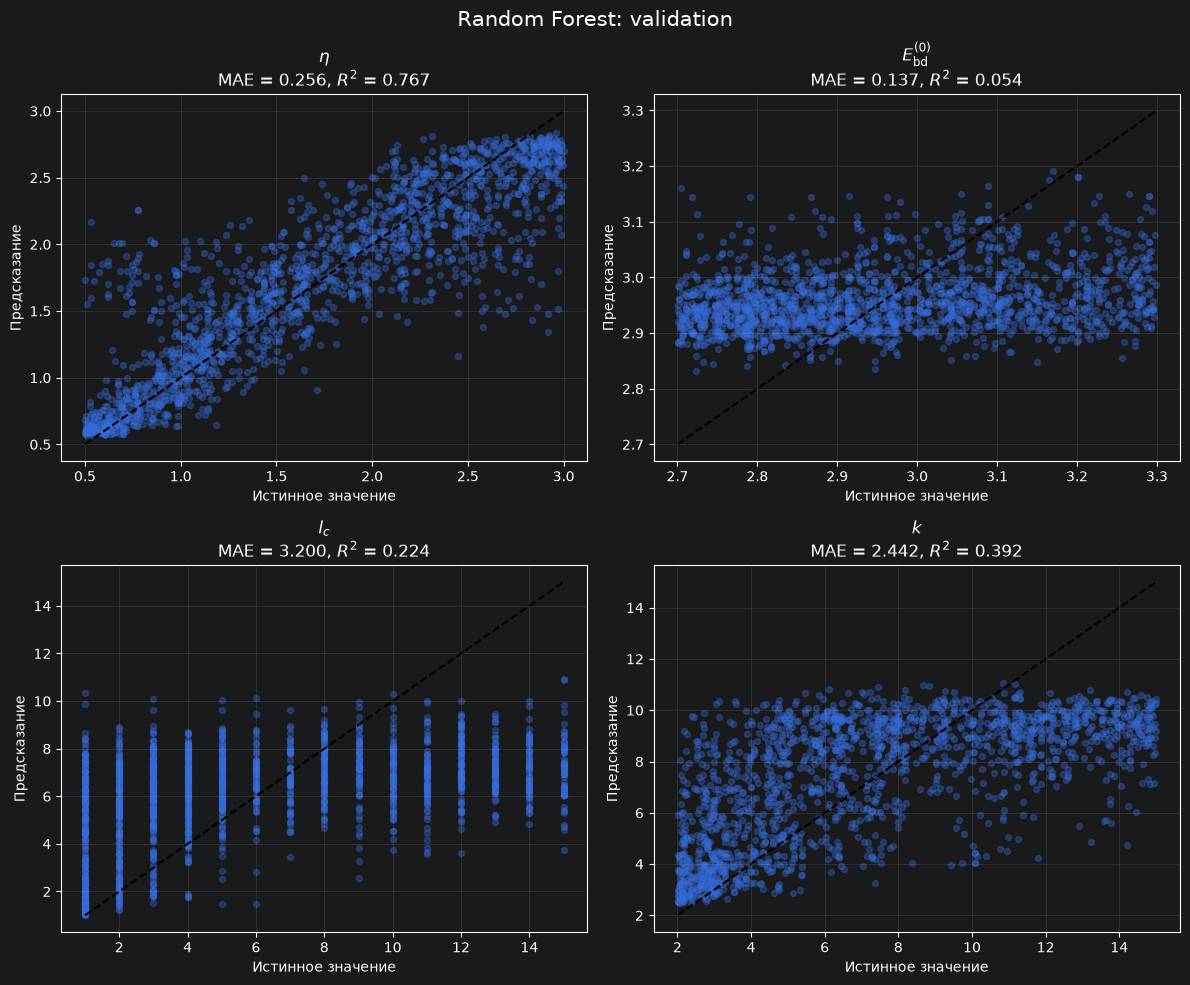

In [21]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
)

axes = axes.ravel()

for ax, target in zip(axes, TARGET_COLUMNS):
    y_true = y_validation[target].to_numpy()
    y_pred = best_rf_predictions[target]

    lower_bound = min(
        y_true.min(),
        y_pred.min(),
    )

    upper_bound = max(
        y_true.max(),
        y_pred.max(),
    )

    mae = mean_absolute_error(
        y_true,
        y_pred,
    )

    r2 = r2_score(
        y_true,
        y_pred,
    )

    ax.scatter(
        y_true,
        y_pred,
        s=18,
        alpha=0.35,
    )

    ax.plot(
        [lower_bound, upper_bound],
        [lower_bound, upper_bound],
        linestyle="--",
        color="black",
        linewidth=1.5,
    )

    ax.set(
        title=(
            f"{TARGET_LABELS[target]}\n"
            f"MAE = {mae:.3f}, "
            f"$R^2$ = {r2:.3f}"
        ),
        xlabel="Истинное значение",
        ylabel="Предсказание",
    )

    ax.grid(alpha=0.2)

fig.suptitle(
    "Random Forest: validation",
    fontsize=15,
)

plt.tight_layout()
plt.show()

## Важность морфологических признаков

Важность оценивается методом permutation importance на validation. Значения одного признака случайно перемешиваются, после чего измеряется увеличение ошибки модели.

Чем сильнее возрастает MAE, тем больше информации о параметре содержит признак.

In [23]:
from sklearn.inspection import permutation_importance

permutation_tables = {}

for target in TARGET_COLUMNS:
    importance_result = permutation_importance(
        estimator=best_rf_models[target],
        X=X_validation,
        y=y_validation[target],
        scoring="neg_mean_absolute_error",
        n_repeats=15,
        random_state=42,
        n_jobs=-1,
    )

    importance_table = pd.DataFrame(
        {
            "feature": FEATURE_COLUMNS,
            "mae_increase": importance_result.importances_mean,
            "importance_std": importance_result.importances_std,
        }
    )

    importance_table = importance_table.sort_values(
        "mae_increase",
        ascending=False,
    ).reset_index(drop=True)

    permutation_tables[target] = importance_table

    print(f"\nГлавные признаки для {target}")

    display(
        importance_table.head(10).round(4)
    )


Главные признаки для eta


,feature,mae_increase,importance_std
0,side_branch_fraction,0.4116,0.0077
1,area_fraction,0.0243,0.0006
2,area,0.0232,0.0006
3,endpoint_count,0.0231,0.0014
4,radius_75,0.0093,0.0016
5,anisotropy,0.0084,0.0015
6,radius_25,0.0064,0.0008
7,lacunarity_8,0.0054,0.0013
8,radius_50,0.0046,0.0009
9,x_std_fraction,0.0038,0.0006



Главные признаки для mean_breakdown_field


,feature,mae_increase,importance_std
0,radius_25,0.0025,0.0004
1,centroid_offset_fraction,0.0012,0.0004
2,endpoint_count,0.0009,0.0004
3,radius_50,0.0008,0.0003
4,area,0.0005,0.0002
5,anisotropy,0.0004,0.0001
6,lacunarity_16,0.0004,0.0001
7,fractal_dimension,0.0003,0.0001
8,area_fraction,0.0003,0.0001
9,radius_75,0.0003,0.0002



Главные признаки для correlation_length


,feature,mae_increase,importance_std
0,endpoint_count,0.3527,0.0139
1,sinuosity,0.1950,0.0166
2,radius_25,0.0787,0.0122
3,depth_fraction,0.0723,0.0053
4,main_path_length,0.0669,0.0058
5,area,0.0621,0.0032
6,max_y,0.0536,0.0020
7,area_fraction,0.0508,0.0026
8,lacunarity_4,0.0473,0.0019
9,height_fraction,0.0460,0.0019



Главные признаки для weibull_shape


,feature,mae_increase,importance_std
0,radius_25,0.4441,0.0291
1,main_path_length,0.2057,0.0131
2,depth_fraction,0.1416,0.0176
3,sinuosity,0.0835,0.0075
4,radius_50,0.0623,0.0175
5,mean_branch_length,0.0551,0.0072
6,branching_density,0.0349,0.0093
7,centroid_offset_fraction,0.0207,0.0058
8,x_std_fraction,0.0157,0.0053
9,max_branch_length,0.0132,0.0036


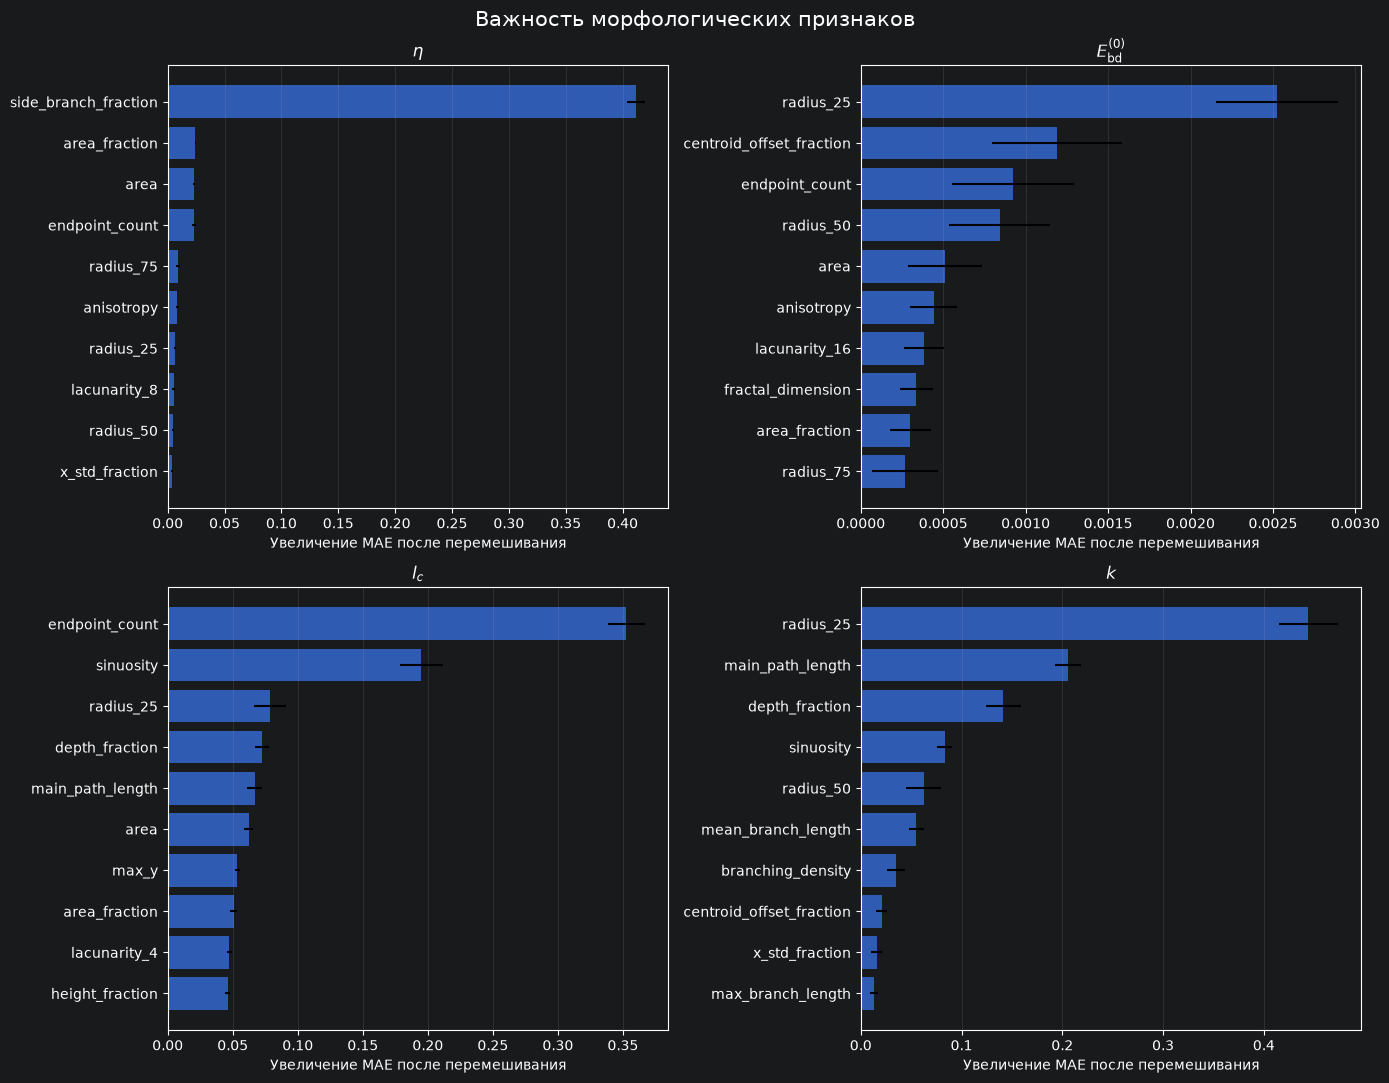

In [25]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11),
)

axes = axes.ravel()

for ax, target in zip(axes, TARGET_COLUMNS):
    top_features = (
        permutation_tables[target]
        .head(10)
        .sort_values("mae_increase")
    )

    ax.barh(
        top_features["feature"],
        top_features["mae_increase"],
        xerr=top_features["importance_std"],
        alpha=0.8,
    )

    ax.set(
        title=TARGET_LABELS[target],
        xlabel="Увеличение MAE после перемешивания",
        ylabel="",
    )

    ax.grid(
        axis="x",
        alpha=0.2,
    )

fig.suptitle(
    "Важность морфологических признаков",
    fontsize=15,
)

plt.tight_layout()
plt.show()

## Финальная оценка на test

После выбора гиперпараметров train и validation объединяются. Финальные модели обучаются на всех доступных обучающих данных и один раз оцениваются на ранее не использованной тестовой выборке.

In [26]:
X_train_full = pd.concat(
    [
        X_train,
        X_validation,
    ],
    axis=0,
    ignore_index=True,
)

y_train_full = pd.concat(
    [
        y_train,
        y_validation,
    ],
    axis=0,
    ignore_index=True,
)

print("Полная обучающая выборка:", X_train_full.shape)
print("Тестовая выборка:", X_test.shape)

Полная обучающая выборка: (8266, 27)
Тестовая выборка: (1933, 27)


In [27]:
final_rf_models = {}
final_test_predictions = {}
final_test_metrics = []

final_baseline_models = {}
final_baseline_metrics = []

for target in TARGET_COLUMNS:
    parameters = best_rf_params[target]

    final_model = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=600,
                    max_features=parameters["max_features"],
                    min_samples_leaf=parameters[
                        "min_samples_leaf"
                    ],
                    max_depth=parameters["max_depth"],
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    final_model.fit(
        X_train_full,
        y_train_full[target],
    )

    test_prediction = final_model.predict(
        X_test
    )

    final_rf_models[target] = final_model
    final_test_predictions[target] = test_prediction

    rf_test_result = calculate_regression_metrics(
        y_true=y_test[target],
        y_pred=test_prediction,
        target=target,
        model_name="Final Random Forest",
        split_name="test",
    )

    final_test_metrics.append(rf_test_result)

    final_baseline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "model",
                DummyRegressor(strategy="median"),
            ),
        ]
    )

    final_baseline.fit(
        X_train_full,
        y_train_full[target],
    )

    baseline_prediction = final_baseline.predict(
        X_test
    )

    final_baseline_models[target] = final_baseline

    baseline_test_result = calculate_regression_metrics(
        y_true=y_test[target],
        y_pred=baseline_prediction,
        target=target,
        model_name="Median baseline",
        split_name="test",
    )

    final_baseline_metrics.append(
        baseline_test_result
    )

    print(f"Готово: {target}")

final_test_metrics = pd.DataFrame(
    final_test_metrics
)

final_baseline_metrics = pd.DataFrame(
    final_baseline_metrics
)

Готово: eta
Готово: mean_breakdown_field
Готово: correlation_length
Готово: weibull_shape


In [28]:
test_comparison = pd.concat(
    [
        final_baseline_metrics,
        final_test_metrics,
    ],
    ignore_index=True,
)

display(
    test_comparison.pivot(
        index="target",
        columns="model",
        values=[
            "mae",
            "normalized_mae",
            "rmse",
            "r2",
        ],
    ).round(4)
)

mae                      normalized_mae  \
model                Final Random Forest Median baseline Final Random Forest   
target                                                                         
correlation_length                3.5317          4.2178              0.2523   
eta                               0.2276          0.6247              0.0911   
mean_breakdown_field              0.1374          0.1407              0.2291   
weibull_shape                     2.5486          3.3468              0.1962   

                                                    rmse                  \
model                Median baseline Final Random Forest Median baseline   
target                                                                     
correlation_length            0.3013              4.2639          5.1206   
eta                           0.2500              0.3103          0.7217   
mean_breakdown_field          0.2346              0.1615          0.1660   
weibull_shape                 0.2577              3.1355          3.9705   

                                      r2                  
model                Final Random Forest Median baseline  
target                                                    
correlation_length                0.0843         -0.3206  
eta                               0.8150         -0.0007  
mean_breakdown_field              0.0532         -0.0005  
weibull_shape                     0.3117         -0.1037

In [29]:
test_baseline_mae = (
    final_baseline_metrics
    .set_index("target")["mae"]
)

test_rf_mae = (
    final_test_metrics
    .set_index("target")["mae"]
)

test_improvement = (
    100
    * (test_baseline_mae - test_rf_mae)
    / test_baseline_mae
)

display(
    test_improvement
    .rename("test_mae_improvement_percent")
    .to_frame()
    .round(2)
)

,test_mae_improvement_percent
target,
eta,63.57
mean_breakdown_field,2.33
correlation_length,16.27
weibull_shape,23.85


In [30]:
test_predictions_table = test_data[
    [
        "run_id",
        "point_id",
        "status",
        *TARGET_COLUMNS,
    ]
].copy()

for target in TARGET_COLUMNS:
    test_predictions_table[
        f"predicted_{target}"
    ] = final_test_predictions[target]

    test_predictions_table[
        f"absolute_error_{target}"
    ] = np.abs(
        test_predictions_table[target]
        - final_test_predictions[target]
    )

display(test_predictions_table.head())

,run_id,point_id,status,eta,mean_breakdown_field,correlation_length,weibull_shape,predicted_eta,absolute_error_eta,predicted_mean_breakdown_field,absolute_error_mean_breakdown_field,predicted_correlation_length,absolute_error_correlation_length,predicted_weibull_shape,absolute_error_weibull_shape
5949,test-000000-m0-g0,test-000000,breakdown,0.799570,2.816857,11,12.415463,0.847783,0.048213,2.927084,0.110227,6.108993,4.891007,9.993838,2.421626
5950,test-000002-m0-g0,test-000002,breakdown,2.294968,2.953033,15,9.404524,2.197620,0.097349,2.968344,0.015311,6.815914,8.184086,9.490133,0.085609
5951,test-000002-m1-g0,test-000002,breakdown,2.294968,2.953033,15,9.404524,2.177226,0.117742,2.946157,0.006875,6.878483,8.121517,10.139589,0.735065
5952,test-000003-m0-g0,test-000003,breakdown,1.646924,3.030428,3,3.293578,1.785590,0.138666,2.931481,0.098947,4.077801,1.077801,3.427102,0.133524
5953,test-000003-m1-g0,test-000003,breakdown,1.646924,3.030428,3,3.293578,2.193895,0.546971,2.967064,0.063364,7.515027,4.515027,3.495283,0.201705


In [31]:
import joblib

MODELS_DIR = RESULTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for target, model in final_rf_models.items():
    model_file = (
        MODELS_DIR
        / f"random_forest_{target}.joblib"
    )

    joblib.dump(
        model,
        model_file,
    )

    print("Сохранена модель:", model_file.name)

test_comparison.to_csv(
    RESULTS_DIR / "test_metrics.csv",
    index=False,
)

test_predictions_table.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False,
)

best_params_table.to_csv(
    RESULTS_DIR / "best_rf_parameters.csv",
)

all_importances = pd.concat(
    [
        table.assign(target=target)
        for target, table
        in permutation_tables.items()
    ],
    ignore_index=True,
)

all_importances.to_csv(
    RESULTS_DIR / "permutation_importance.csv",
    index=False,
)

print("Результаты сохранены в:", RESULTS_DIR)

Сохранена модель: random_forest_eta.joblib
Сохранена модель: random_forest_mean_breakdown_field.joblib
Сохранена модель: random_forest_correlation_length.joblib
Сохранена модель: random_forest_weibull_shape.joblib
Результаты сохранены в: /home/artur/PycharmProjects/Mathprac/results/inverse_ml


## Вывод

По 27 морфологическим признакам построены отдельные модели Random Forest для восстановления четырёх параметров DBM. Разделение выполнено по `point_id` и `disorder_seed`, поэтому повторные реализации не пересекаются между обучением и проверкой.

На независимой тестовой выборке наиболее точно восстанавливается параметр $\eta$: MAE равна 0.228, что на 63.6% лучше медианного baseline. Главным признаком оказалась доля клеток в боковых ветвях.

Параметр Вейбулла $k$ восстанавливается умеренно точно: MAE равна 2.549, улучшение относительно baseline составляет 23.9%. Наиболее информативны радиальное распределение массы, длина основного пути и глубина дерева.

Для корреляционной длины $l_c$ получена MAE 3.532 и улучшение 16.3%. Основную информацию несут количество концов и извилистость канала.

Средний порог пробоя $E_{\mathrm{bd}}^{(0)}$ практически не восстанавливается по морфологии уже выросшего дерева: улучшение составляет только 2.3%. Это согласуется с тем, что порог сильнее влияет на факт старта канала, чем на его последующую форму.